In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

In [2]:
# Load dataset
df = pd.read_csv("/content/Mall_Customers.csv")

In [3]:
# Display first 5 rows
print(df.head())

   CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


In [4]:
# Select features
X = df[["Annual Income (k$)", "Spending Score (1-100)"]]

In [5]:
# Elbow Method
inertia = []

for k in range(1, 11):
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(X)
    inertia.append(model.inertia_)

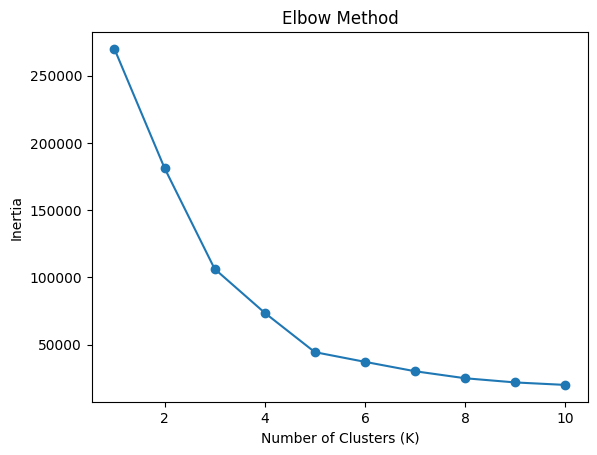

In [6]:
# Plot Elbow Curve
plt.plot(range(1, 11), inertia, marker="o")

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.show()

In [7]:
# Create K-Means model
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

# Train the model
kmeans.fit(X)

KMeans(n_clusters=5, n_init=10, random_state=42)

In [8]:
# Assign clusters
df["Cluster"] = kmeans.labels_

In [9]:
# Print cluster centers
print("\nCluster Centers:")
print(kmeans.cluster_centers_)


Cluster Centers:
[[55.2962963  49.51851852]
 [86.53846154 82.12820513]
 [25.72727273 79.36363636]
 [88.2        17.11428571]
 [26.30434783 20.91304348]]


In [10]:
# Print customer segmentation
print("\nCustomer Segmentation:")
print(df[[
    "CustomerID",
    "Annual Income (k$)",
    "Spending Score (1-100)",
    "Cluster"
]])


Customer Segmentation:
     CustomerID  Annual Income (k$)  Spending Score (1-100)  Cluster
0             1                  15                      39        4
1             2                  15                      81        2
2             3                  16                       6        4
3             4                  16                      77        2
4             5                  17                      40        4
..          ...                 ...                     ...      ...
195         196                 120                      79        1
196         197                 126                      28        3
197         198                 126                      74        1
198         199                 137                      18        3
199         200                 137                      83        1

[200 rows x 4 columns]


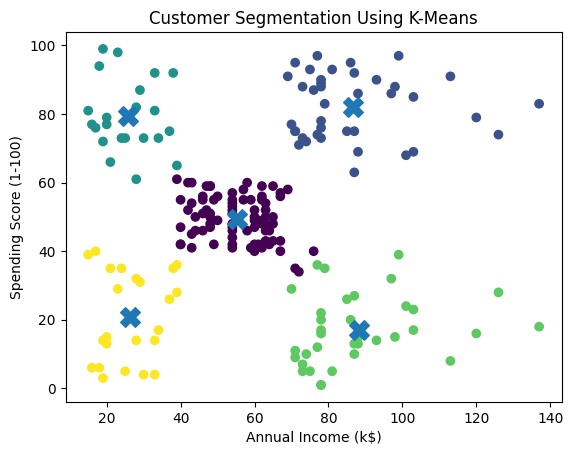

In [11]:
# Visualize clusters
plt.scatter(
    X["Annual Income (k$)"],
    X["Spending Score (1-100)"],
    c=df["Cluster"]
)

# Plot cluster centers
plt.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    marker="X",
    s=200
)

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Customer Segmentation Using K-Means")

plt.show()